# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

## **Tahap 2: Import Library (Fokus: Preprocessing Data)**

Pada tahap awal ini, mengimpor pustaka (*library*) Python yang krusial untuk melakukan inspeksi, pembersihan (*cleaning*), dan penyiapan (*preprocessing*) data teks ulasan Mobile Legends. Proses ini sangat penting agar data mentah siap digunakan untuk pemodelan *Machine Learning*.

### **Pustaka yang Digunakan:**
1. **Manipulasi & Analisis Data:** `pandas` dan `numpy` untuk membaca dataset dan mengolah struktur tabel.
2. **Visualisasi Data:** `matplotlib` dan `seaborn` untuk melihat distribusi rating atau jumlah ulasan.
3. **Pembersihan Teks (NLP):**
   * `re` (Regular Expression) untuk menghapus karakter khusus, angka, dan emoji.
   * `string` untuk manipulasi teks standar (menghapus tanda baca).
4. **Sastrawi (Pustaka Bahasa Indonesia):**
   * `StopWordRemoverFactory` untuk menghapus kata-kata yang tidak bermakna (seperti: "yang", "di", "dan").
   * `StemmerFactory` untuk mengubah kata berimbuhan menjadi kata dasar (misal: "mendownload" menjadi "download").

In [1]:
# ==============================================================================
# 1. INSTALASI LIBRARY KHUSUS (BAHASA INDONESIA & KAGGLE)
# ==============================================================================
# Menginstall library Sastrawi untuk NLP Indonesia dan Kagglehub untuk unduh dataset
!pip install Sastrawi kagglehub -q

# ==============================================================================
# 2. IMPORT LIBRARY UNTUK DATA MANIPULATION, VISUALIZATION & SYSTEM
# ==============================================================================
import os
import re
import glob
import string
import shutil
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time


# Import fungsi stopword dan stemming khusus Bahasa Indonesia dari Sastrawi
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# ==============================================================================
# 3. INISIALISASI OBJECT PREPROCESSING NLP
# ==============================================================================
# Inisialisasi stopword remover
stopword_factory = StopWordRemoverFactory()
indonesian_stopwords = stopword_factory.get_stop_words()
stopword_remover = stopword_factory.create_stop_word_remover()

# Inisialisasi stemmer
stemmer_factory = StemmerFactory()
indonesian_stemmer = stemmer_factory.create_stemmer()

# ==============================================================================
# 4. INISIALISASI STRUKTUR FOLDER (BLUEPRINT WORKSPACE)
# ==============================================================================
# Tentukan nama root berdasarkan nama Anda
NAMA_SISWA = "Ridho-nur-mahmudah"
ROOT_DIR = f"Eksperimen_SML_{NAMA_SISWA}"

# Definisikan path folder sesuai struktur blueprint
RAW_DIR = os.path.join(ROOT_DIR, "dataset_raw")
PREPROCESSING_DIR = os.path.join(ROOT_DIR, "preprocessing")
PREPROCESSED_DATA_DIR = os.path.join(PREPROCESSING_DIR, "dataset")

# Membuat folder secara rekursif jika belum ada
os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(PREPROCESSING_DIR, exist_ok=True)
os.makedirs(PREPROCESSED_DATA_DIR, exist_ok=True)

print("-" * 60)
print("✓ Semua library dan objek preprocessing berhasil di-import!")
print("✓ Struktur folder eksperimen berhasil diinisialisasi:")
print(f"  └── {ROOT_DIR}/")
print(f"      ├── dataset_raw/")
print(f"      └── preprocessing/")
print(f"          └── dataset/")
print("-" * 60)

------------------------------------------------------------
✓ Semua library dan objek preprocessing berhasil di-import!
✓ Struktur folder eksperimen berhasil diinisialisasi:
  └── Eksperimen_SML_Ridho-nur-mahmudah/
      ├── dataset_raw/
      └── preprocessing/
          └── dataset/
------------------------------------------------------------


# **3. Memuat Dataset**

## **Tahap 3: Memuat Dataset Menggunakan Kagglehub**

Pada tahap ini, kita akan mengunduh dataset ulasan **Mobile Legends - Indonesia** menggunakan pustaka resmi terbaru dari Kaggle, yaitu `kagglehub`. Pustaka ini secara otomatis akan mengunduh versi terbaru dari dataset `qoisalqorni/dataset-playstore-mobile-legend-indonesia` langsung ke dalam *environment* Google Colab tanpa perlu mengonfigurasi file kredensial secara manual.

Setelah file berhasil diunduh, kita akan melacak jalur foldernya (*path*), mencari file CSV di dalamnya, kemudian memuat data tersebut ke dalam `pandas` DataFrame untuk dilakukan inspeksi awal.

In [2]:
# ==============================================================================
# 1. PROSES DOWNLOAD DATASET MENGGUNAKAN KAGGLEHUB
# ==============================================================================
print("Sedang mengunduh dataset dari Kaggle...")
path = kagglehub.dataset_download("qoisalqorni/dataset-playstore-mobile-legend-indonesia")

print("✓ Dataset berhasil diunduh!")
print("Path cache internal:", path)

# ==============================================================================
# 2. MENYALIN DAN MEMUAT FILE CSV KE DIREKTORI UTAMA GOOGLE COLAB (FILES)
# ==============================================================================
csv_files = glob.glob(os.path.join(path, "*.csv"))

if csv_files:
    file_asal = csv_files[0]

    # Menentukan nama file baru di direktori
    nama_file_baru = "dataset_mobile_legends.csv"
    file_tujuan = os.path.join("Eksperimen_SML_Ridho-nur-mahmudah/dataset_raw", nama_file_baru)

    # Proses penyalinan file
    shutil.copy(file_asal, file_tujuan)
    print(f"✓ File berhasil disalin ke panel file Colab Anda dengan nama: '{nama_file_baru}'")

    # Membaca file dari lokasi baru
    df = pd.read_csv(file_tujuan)
    print("✓ Data berhasil dimuat ke dalam DataFrame 'df'.")
else:
    print(f"✗ File CSV tidak ditemukan di lokasi {path}. Periksa kembali isi dataset.")

# ==============================================================================
# 3. INSPEKSI AWAL DATASET (STANDAR NLP / ML TERAPAN)
# ==============================================================================
print("\n" + "="*50)
print("INSPEKSI AWAL DATASET")
print("="*50)

# A. Dimensi Data
print(f"1. Dimensi Dataset: {df.shape[0]} baris dan {df.shape[1]} kolom.\n")

# B. Menampilkan 5 Data Teratas
print("2. Lima baris pertama dataset:")
display(df.head())

# C. Informasi Kolom, Tipe Data, dan Missing Values
print("\n3. Informasi Tipe Data dan Missing Values:")
print(df.info())

# D. Cek Sampel Data Teks (Unstructured Data Check)
kolom_teks = None
for col in ['content', 'text', 'review', 'ulasan', 'Comment']:
    if col in df.columns:
        kolom_teks = col
        break

if kolom_teks:
    print(f"\n4. Contoh 3 teks ulasan mentah pada kolom '{kolom_teks}':")
    for i, teks in enumerate(df[kolom_teks].dropna().head(3)):
        print(f"   [{i+1}] {teks}")
else:
    print("\n4. Peringatan: Kolom teks ulasan tidak otomatis terdeteksi. Silakan sesuaikan nama kolom teks Anda manual.")

Sedang mengunduh dataset dari Kaggle...
Using Colab cache for faster access to the 'dataset-playstore-mobile-legend-indonesia' dataset.
✓ Dataset berhasil diunduh!
Path cache internal: /kaggle/input/dataset-playstore-mobile-legend-indonesia
✓ File berhasil disalin ke panel file Colab Anda dengan nama: 'dataset_mobile_legends.csv'
✓ Data berhasil dimuat ke dalam DataFrame 'df'.

INSPEKSI AWAL DATASET
1. Dimensi Dataset: 1200 baris dan 13 kolom.

2. Lima baris pertama dataset:


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,sortOrder,appId
0,ca3472f1-3cbf-4d51-9699-99fa7ffe5b61,Yanto Botak (Ai),https://play-lh.googleusercontent.com/a-/ALV-U...,Gamenya bagus tapi saat bermain kadang layar m...,3,1567,1.7.94.8681,2023-08-01 07:57:01,NaN,NaN,1.7.94.8681,most_relevant,com.mobile.legends
1,b5a15f6e-267d-460a-8cce-c08254383d80,Dhe Shogun,https://play-lh.googleusercontent.com/a/ACg8oc...,"Saya memiliki keluhan terhadap game ini, saya ...",1,1072,1.8.8.8811,2023-08-08 12:26:47,NaN,NaN,1.8.8.8811,most_relevant,com.mobile.legends
2,18b707a7-f4d9-4b3c-b7d8-c428e86f4f4f,Elysa Devita,https://play-lh.googleusercontent.com/a-/ALV-U...,"Saya pemain lama emel, makin lama emel sering ...",3,181,1.8.8.8811,2023-08-09 07:47:52,"Dear Hero,\nTerima kasih atas tanggapan Anda, ...",2023-08-13 10:42:07,1.8.8.8811,most_relevant,com.mobile.legends
3,6c81fd1d-0da8-4baa-9774-f91be3b2c913,Meira Arika,https://play-lh.googleusercontent.com/a-/ALV-U...,Tolong kembalikan performa Mobile Legends sepe...,4,19953,1.8.8.8811,2023-08-09 15:42:44,NaN,NaN,1.8.8.8811,most_relevant,com.mobile.legends
4,aa2126cd-0464-493d-898b-a2ef5ea7fdde,Ryan Setiawan,https://play-lh.googleusercontent.com/a-/ALV-U...,Tolong diperbaiki sinyal dan kapasitas penyimp...,5,2446,1.8.8.8811,2023-08-10 00:15:55,NaN,NaN,1.8.8.8811,most_relevant,com.mobile.legends



3. Informasi Tipe Data dan Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              1200 non-null   object
 1   userName              1200 non-null   object
 2   userImage             1200 non-null   object
 3   content               1200 non-null   object
 4   score                 1200 non-null   int64 
 5   thumbsUpCount         1200 non-null   int64 
 6   reviewCreatedVersion  940 non-null    object
 7   at                    1200 non-null   object
 8   replyContent          109 non-null    object
 9   repliedAt             109 non-null    object
 10  appVersion            940 non-null    object
 11  sortOrder             1200 non-null   object
 12  appId                 1200 non-null   object
dtypes: int64(2), object(11)
memory usage: 122.0+ KB
None

4. Contoh 3 teks ulasan mentah pada kolo

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, kita akan mengeksplorasi dataset ulasan Mobile Legends untuk menarik informasi penting sebelum masuk ke pemrosesan teks. Beberapa aspek utama yang akan kita analisis meliputi:
1. **Distribusi Skor/Rating:** Melihat apakah pengguna lebih banyak memberikan sentimen positif (bintang 4-5) atau negatif (bintang 1-2).
2. **Korelasi Thumbs Up:** Mengetahui apakah ulasan dengan rating rendah cenderung mendapatkan kesepakatan (*likes/thumbs up*) lebih banyak dari pengguna lain.
3. **Analisis Respon Pengembang:** Melihat seberapa aktif pihak pengembang (*developer*) membalas ulasan yang masuk.
4. **Distribusi Panjang Karakter Teks:** Memahami karakteristik panjang ulasan pengguna.

/tmp/ipykernel_16952/692985206.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='score', data=df, palette='viridis')


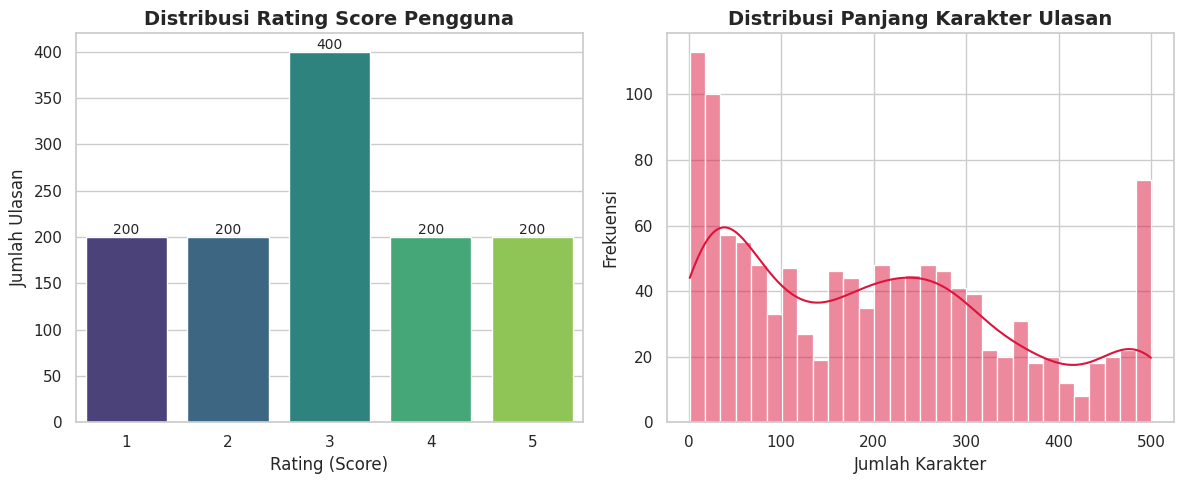


5 ULASAN DENGAN DUKUNGAN (THUMBS UP) TERTINGGI DARI PENGGUNA LAIN
Rating: ⭐ 4 | Disetujui: 19953 Pengguna
Ulasan: Tolong kembalikan performa Mobile Legends seperti dahulu. Saat sinyal tidak mudah jumping-jumping. Tolong sesuaikan tim sendiri dan tim lawan. "Tolong...
------------------------------------------------------------
Rating: ⭐ 2 | Disetujui: 14552 Pengguna
Ulasan: Lebih baik pas S29, tidak banyak bug, jaringan stabil, di game tidak berat.. Di season 30 ini banyak perubahan, membuat kami tidak nyaman bermain.. Te...
------------------------------------------------------------
Rating: ⭐ 1 | Disetujui: 13833 Pengguna
Ulasan: Sebenarnya game ini bagus, cuman mohon untuk memperbaiki macthmaking nya moonton (terutama pada rekan tim) sehingga bisa seimbang, jangan ngasih musuh...
------------------------------------------------------------
Rating: ⭐ 5 | Disetujui: 9584 Pengguna
Ulasan: Untuk keseluruhan sudah bagus. tapi setelah update ada beberapa yang harus di perbaiki. 1. Terlal

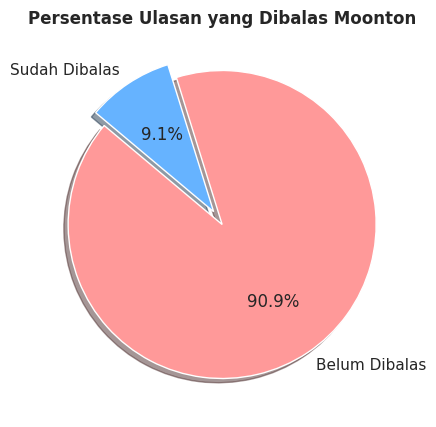

In [3]:
# Mengatur gaya visualisasi data
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# ==============================================================================
# 1. DISTRIBUSI SCORE / RATING
# ==============================================================================
plt.subplot(1, 2, 1)
ax = sns.countplot(x='score', data=df, palette='viridis')
plt.title('Distribusi Rating Score Pengguna', fontsize=14, fontweight='bold')
plt.xlabel('Rating (Score)', fontsize=12)
plt.ylabel('Jumlah Ulasan', fontsize=12)

# Menambahkan label jumlah di atas bar chart
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)

# ==============================================================================
# 2. ANALISIS PANJANG KARAKTER ULASAN
# ==============================================================================
# Membuat kolom baru untuk menghitung jumlah karakter dalam ulasan
df['review_length'] = df['content'].astype(str).apply(len)

plt.subplot(1, 2, 2)
sns.histplot(df['review_length'], bins=30, kde=True, color='crimson')
plt.title('Distribusi Panjang Karakter Ulasan', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Karakter', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)

plt.tight_layout()
plt.show()

# ==============================================================================
# 3. KORELASI SCORE DENGAN THUMBS UP COUNT (Ulasan Paling Berpengaruh)
# ==============================================================================
print("\n" + "="*60)
print("5 ULASAN DENGAN DUKUNGAN (THUMBS UP) TERTINGGI DARI PENGGUNA LAIN")
print("="*60)
top_liked_reviews = df.sort_values(by='thumbsUpCount', ascending=False)[['score', 'thumbsUpCount', 'content']].head(5)
for idx, row in top_liked_reviews.iterrows():
    print(f"Rating: ⭐ {row['score']} | Disetujui: {row['thumbsUpCount']} Pengguna")
    print(f"Ulasan: {row['content'][:150]}...")
    print("-" * 60)

# ==============================================================================
# 4. ANALISIS RESPON PENGEMBANG (REPLY RATIO)
# ==============================================================================
# Menghitung jumlah ulasan yang dibalas (berdasarkan kolom replyContent)
total_reviews = len(df)
replied_reviews = df['replyContent'].notna().sum()
not_replied_reviews = total_reviews - replied_reviews

print("\n" + "="*60)
print("PERSENTASE RESPON PENGEMBANG (DEVELOPER REPLY RATIO)")
print("="*60)
print(f"Total Ulasan           : {total_reviews}")
print(f"Ulasan Dibalas Dev     : {replied_reviews} ({replied_reviews/total_reviews*100:.2f}%)")
print(f"Ulasan Diabaikan/Belum : {not_replied_reviews} ({not_replied_reviews/total_reviews*100:.2f}%)")

# Visualisasi Reply Ratio menggunakan Pie Chart
plt.figure(figsize=(5, 5))
labels = ['Belum Dibalas', 'Sudah Dibalas']
sizes = [not_replied_reviews, replied_reviews]
colors = ['#ff9999','#66b3ff']
explode = (0, 0.1)  # Menonjolkan potongan 'Sudah Dibalas'

plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140)
plt.title('Persentase Ulasan yang Dibalas Moonton', fontsize=12, fontweight='bold')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, kita melakukan *data preprocessing* untuk memastikan kualitas data ulasan (*unstructured data*) bersih dan siap digunakan pada model machine learning. Berdasarkan karakteristik dataset ulasan Mobile Legends ini, langkah preprocessing yang krusial untuk diterapkan meliputi:

1. **Pembersihan Nilai Kosong (Missing Values):** Menghapus baris teks ulasan yang kosong pada kolom `content`.
2. **Penanganan Data Duplikat:** Menghapus ulasan yang terduplikasi (misalnya akibat *spamting* atau kegagalan sistem penarikan data).
3. **Pembersihan Teks (Text Cleansing):** Mengubah teks menjadi huruf kecil (*case folding*), menghapus tanda baca, angka, emoji, serta spasi berlebih.
4. **Binning & Encoding (Pelabelan Sentimen):** Mengelompokkan rating angka (`score`) menjadi label sentimen kategorikal:
   * **Negatif (0):** Score 1 - 2
   * **Netral (1):** Score 3
   * **Positif (2):** Score 4 - 5

In [4]:
print("==================================================")
print("MEMULAI PROSES PREPROCESSING DATA")
print("==================================================\n")

# ==============================================================================
# 1. MENANGANI DATA KOSONG (MISSING VALUES) & DUPLIKAT
# ==============================================================================
# Memastikan kolom konten teks tidak ada yang bernilai NaN
df_clean = df.dropna(subset=['content']).copy()
print(f"[1] Baris setelah hapus missing values pada 'content': {df_clean.shape[0]}")

# Menghapus data ulasan yang isinya sama persis (Duplikat)
df_clean = df_clean.drop_duplicates(subset=['content'])
print(f"[2] Baris setelah hapus ulasan duplikat           : {df_clean.shape[0]}")


# ==============================================================================
# 2. BINNING & ENCODING DATA KATEGORIKAL (Membuat Label Sentimen)
# ==============================================================================
# Mengelompokkan score 1-2 menjadi 0 (Negatif), 3 menjadi 1 (Netral), 4-5 menjadi 2 (Positif)
def tentukan_sentimen(skor):
    if skor <= 2:
        return 0  # Negatif
    elif skor == 3:
        return 1  # Netral
    else:
        return 2  # Positif

df_clean['sentiment_label'] = df_clean['score'].apply(tentukan_sentimen)
print("[3] Proses Binning & Labeling Sentimen selesai.")


# ==============================================================================
# 3. TEXT CLEANSING (PEMBERSIHAN DATA TEKS TIDAK TERSTRUKTUR)
# ==============================================================================
def bersihkan_teks(text):
    # a. Case Folding: Mengubah teks menjadi huruf kecil semua
    text = text.lower()

    # b. Menghapus URL atau Link jika ada
    text = re.sub(r'https?://\s+|www\.\s+', '', text)

    # c. Menghapus Angka
    text = re.sub(r'\d+', '', text)

    # d. Menghapus Tanda Baca (Punctuation) dan Karakter Khusus
    text = text.translate(str.maketrans('', '', string.punctuation))

    # e. Menghapus karakter non-ascii / Emoji / Karakter aneh lainnya
    text = text.encode('ascii', 'ignore').decode('ascii')

    # f. Menghapus spasi berlebih di awal, akhir, atau tengah kata
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Menerapkan fungsi pembersihan ke kolom ulasan
df_clean['content_clean'] = df_clean['content'].apply(bersihkan_teks)

# Menghapus baris baru jika setelah dibersihkan teksnya menjadi kosong ""
df_clean = df_clean[df_clean['content_clean'] != ""]
print("[4] Proses Text Cleansing (Case Folding, No-Punctuation, No-Emoji) selesai.\n")


# ==============================================================================
# 4. MENAMPILKAN HASIL PERBANDINGAN SEBELUM VS SESUDAH PREPROCESSING
# ==============================================================================
print("="*60)
print("HASIL PERBANDINGAN DATA SEBELUM VS SESUDAH PREPROCESSING")
print("="*60)
sampel_data = df_clean[['content', 'content_clean', 'score', 'sentiment_label']].head(2)

for i, (idx, row) in enumerate(sampel_data.iterrows()):
    print(f"Data Sampel ke-{i+1}:")
    print(f"  • Skor Asli      : {row['score']} -> Label Sentimen: {row['sentiment_label']}")
    print(f"  • Teks Mentah    : {row['content'][:140]}...")
    print(f"  • Teks Bersih    : {row['content_clean'][:140]}...")
    print("-" * 60)

print(f"\n✓ Preprocessing Selesai! Dimensi Data Akhir: {df_clean.shape[0]} baris.")

MEMULAI PROSES PREPROCESSING DATA

[1] Baris setelah hapus missing values pada 'content': 1200
[2] Baris setelah hapus ulasan duplikat           : 1182
[3] Proses Binning & Labeling Sentimen selesai.
[4] Proses Text Cleansing (Case Folding, No-Punctuation, No-Emoji) selesai.

HASIL PERBANDINGAN DATA SEBELUM VS SESUDAH PREPROCESSING
Data Sampel ke-1:
  • Skor Asli      : 3 -> Label Sentimen: 1
  • Teks Mentah    : Gamenya bagus tapi saat bermain kadang layar membeku dan tidak bisa di apa apakan dan solusinya login ulang dan beberapa hero tidak seimbang...
  • Teks Bersih    : gamenya bagus tapi saat bermain kadang layar membeku dan tidak bisa di apa apakan dan solusinya login ulang dan beberapa hero tidak seimbang...
------------------------------------------------------------
Data Sampel ke-2:
  • Skor Asli      : 1 -> Label Sentimen: 0
  • Teks Mentah    : Saya memiliki keluhan terhadap game ini, saya selalu mendapatkan tim yang tidak dapat di andalkan dalam permainan, saya mengalami 

### **5.1. Stemming (Mengubah Kata ke Bentuk Dasar)**

Pada tahap ini, kita akan melakukan proses *Stemming* khusus untuk Bahasa Indonesia menggunakan pustaka **Sastrawi** yang telah di-import sebelumnya (`indonesian_stemmer`). Proses ini bertujuan untuk memotong semua imbuhan (awalan, sisipan, akhiran) pada kata ulasan agar kembali ke kata dasarnya.

*Contoh perubahan:*
* "gamenya" $\rightarrow$ "game"
* "bermain" $\rightarrow$ "main"
* "membeku" $\rightarrow$ "beku"
* "kekalahan" $\rightarrow$ "kalah"

Langkah ini sangat krusial dalam klasifikasi teks agar model tidak memperlakukan kata "bermain", "dimainkan", dan "permainan" sebagai tiga kata yang berbeda secara makna dasar.

In [5]:
print("==================================================")
print("MEMULAI PROSES STEMMING (KATA DASAR)")
print("==================================================")
print("Catatan: Proses ini membutuhkan waktu beberapa saat...")

# Catat waktu mulai untuk melihat durasi proses
start_time = time.time()

# Fungsi untuk menerapkan stemming Sastrawi pada setiap baris teks
def ubah_ke_kata_dasar(teks):
    # indonesian_stemmer sudah diinisialisasi di library import awal
    return indonesian_stemmer.stem(teks)

# Menerapkan stemming ke kolom 'content_clean' yang sudah dibersihkan sebelumnya
df_clean['content_stemmed'] = df_clean['content_clean'].apply(ubah_ke_kata_dasar)

# Menghitung durasi proses komputasi
end_time = time.time()
durasi = end_time - start_time

print(f"✓ Proses Stemming selesai dalam waktu: {durasi:.2f} detik.\n")

# ==============================================================================
# MENAMPILKAN HASIL PERBANDINGAN SEBELUM VS SESUDAH STEMMING
# ==============================================================================
print("="*75)
print("HASIL PERBANDINGAN TEKS BERSIH VS TEKS SETELAH STEMMING (KATA DASAR)")
print("="*75)
sampel_stem = df_clean[['content_clean', 'content_stemmed']].head(3)

for i, (idx, row) in enumerate(sampel_stem.iterrows()):
    print(f"Ulasan ke-{i+1}:")
    print(f"  • Sebelum Stemming : {row['content_clean'][:120]}...")
    print(f"  • Sesudah Stemming : {row['content_stemmed'][:120]}...")
    print("-" * 75)

MEMULAI PROSES STEMMING (KATA DASAR)
Catatan: Proses ini membutuhkan waktu beberapa saat...
✓ Proses Stemming selesai dalam waktu: 388.59 detik.

HASIL PERBANDINGAN TEKS BERSIH VS TEKS SETELAH STEMMING (KATA DASAR)
Ulasan ke-1:
  • Sebelum Stemming : gamenya bagus tapi saat bermain kadang layar membeku dan tidak bisa di apa apakan dan solusinya login ulang dan beberapa...
  • Sesudah Stemming : gamenya bagus tapi saat main kadang layar beku dan tidak bisa di apa apa dan solusi login ulang dan beberapa hero tidak ...
---------------------------------------------------------------------------
Ulasan ke-2:
  • Sebelum Stemming : saya memiliki keluhan terhadap game ini saya selalu mendapatkan tim yang tidak dapat di andalkan dalam permainan saya me...
  • Sesudah Stemming : saya milik keluh hadap game ini saya selalu dapat tim yang tidak dapat di andal dalam main saya alami kalah banyak kali ...
---------------------------------------------------------------------------
Ulasan ke-3:
  • Se

### **5.2. Menyimpan Hasil Preprocessing ke Google Colab File**

Setelah seluruh rangkaian proses *data preprocessing* selesai—mulai dari penanganan *missing values*, pembersihan teks dari karakter pengganggu, pembentukan label sentimen (*binning*), hingga pengubahan kata ke bentuk dasar (*stemming*)—kita perlu menyimpan dataset yang telah bersih ini menjadi file CSV baru.

File ini akan disimpan langsung ke direktori utama Google Colab (`/content/`) agar data yang sudah siap latih (*ready-to-use*) tidak hilang jika *runtime* Colab terputus dan bisa langsung digunakan pada tahap pemodelan selanjutnya.

In [6]:
import os

print("==================================================")
print("PROSES PENYIMPANAN DATASET HASIL PREPROCESSING")
print("==================================================")

# Menentukan nama dan path file baru untuk hasil preprocessing
nama_file_preprocessed = "dataset_mobile_legends_preprocessed.csv"
path_penyimpanan = os.path.join("Eksperimen_SML_Ridho-nur-mahmudah/preprocessing/dataset", nama_file_preprocessed)

# Menyimpan dataframe ke dalam bentuk CSV
# index=False digunakan agar kolom nomor baris bawaan pandas tidak ikut tersimpan sebagai kolom baru
df_clean.to_csv(path_penyimpanan, index=False)

print(f"✓ Berhasil! Dataset bersih telah disimpan di panel file Colab.")
print(f"  Nama File : {nama_file_preprocessed}")
print(f"  Lokasi    : {path_penyimpanan}\n")

# ==============================================================================
# VERIFIKASI FILE YANG TERSIMPAN
# ==============================================================================
# Memastikan kembali file benar-benar ada dan bisa dibaca dengan baik
if os.path.exists(path_penyimpanan):
    df_cek = pd.read_csv(path_penyimpanan)
    print("="*60)
    print("VERIFIKASI FILE TERFORMAT")
    print("="*60)
    print(f"• Total Baris & Kolom Tersimpan : {df_cek.shape[0]} baris, {df_cek.shape[1]} kolom")
    print(f"• Kolom yang tersedia           : {list(df_cek.columns)}")
    print("• Sampel 2 baris kolom teks siap pakai:")
    display(df_cek[['content_clean', 'content_stemmed', 'sentiment_label']].head(2))
else:
    print("✗ Peringatan: File gagal ditemukan di direktori target.")

PROSES PENYIMPANAN DATASET HASIL PREPROCESSING
✓ Berhasil! Dataset bersih telah disimpan di panel file Colab.
  Nama File : dataset_mobile_legends_preprocessed.csv
  Lokasi    : Eksperimen_SML_Ridho-nur-mahmudah/preprocessing/dataset/dataset_mobile_legends_preprocessed.csv

VERIFIKASI FILE TERFORMAT
• Total Baris & Kolom Tersimpan : 1175 baris, 17 kolom
• Kolom yang tersedia           : ['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion', 'sortOrder', 'appId', 'review_length', 'sentiment_label', 'content_clean', 'content_stemmed']
• Sampel 2 baris kolom teks siap pakai:


,content_clean,content_stemmed,sentiment_label
0,gamenya bagus tapi saat bermain kadang layar m...,gamenya bagus tapi saat main kadang layar beku...,1
1,saya memiliki keluhan terhadap game ini saya s...,saya milik keluh hadap game ini saya selalu da...,0


# **6. Automate Preprocessing**

Pada tahap akhir pemrosesan data ini, kita akan melakukan otomatisasi (*automation*) dengan menyatukan seluruh fungsi preprocessing yang telah diuji sebelumnya—mulai dari *missing values handling*, *text cleansing*, *binning* label sentimen, hingga *stemming* Bahasa Indonesia menggunakan Sastrawi.

Seluruh logika ini akan disimpan secara otomatis ke dalam sebuah file skrip Python bernama `automate_Ridho-nur-mahmudah.py`. Dengan adanya file otomasi ini, Anda atau tim pengembang lain dapat melakukan pembersihan pada dataset ulasan baru yang sejenis hanya dengan sekali panggil, menjaga konsistensi data, dan mempercepat alur kerja (*pipeline*) produksi *Machine Learning*.

In [7]:
# --- 4. DEFINISI ISI KONTEN SKRIP OTOMASI PYTHON (Sinkron & Presisi) ---
automate_script_content = r"""import pandas as pd
import numpy as np
import re
import string
import os
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.preprocessing import StandardScaler

def main():
    # --- A. CONFIGURASI PATH BERDASARKAN STRUKTUR WORKSPACE ---
    ROOT_DIR = 'Eksperimen_SML_Ridho-nur-mahmudah'
    INPUT_FILE = os.path.join(ROOT_DIR, 'dataset_raw', 'dataset_mobile_legends.csv')

    # Path folder output untuk namadataset_preprocessing
    OUTPUT_DIR = os.path.join(ROOT_DIR, 'preprocessing', 'ndataset')
    OUTPUT_FILE = os.path.join(OUTPUT_DIR, 'dataset_mobile_legends_preprocessed.csv')
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # --- B. LOAD DATA ---
    try:
        if not os.path.exists(INPUT_FILE):
            print(f"[!] Error: File input {INPUT_FILE} tidak ditemukan.")
            return

        df = pd.read_csv(INPUT_FILE)
        print(f"[*] Berhasil memuat data mentah dari: {INPUT_FILE}")
    except Exception as e:
        print(f"[!] Error saat memuat file: {e}")
        return

    # --- C. DROP MISSING VALUES & DUPLICATES ---
    df = df.dropna(subset=['content']).copy()
    df = df.drop_duplicates(subset=['content'])

    # --- D. BINNING LABEL SENTIMEN ---
    def tentukan_sentimen(skor):
        if skor <= 2:
            return 0  # Negatif
        elif skor == 3:
            return 1  # Netral
        else:
            return 2  # Positif

    if 'score' in df.columns:
        df['sentiment_label'] = df['score'].apply(tentukan_sentimen)

    # --- E. SETUP STOPWORDS, STEMMER & SLANG DICTIONARY ---
    factory_sw = StopWordRemoverFactory()
    stop_words = set(factory_sw.get_stop_words())

    # Pertahankan kata negasi/krusial untuk analisis sentimen game
    removable = {'tidak', 'kurang', 'lama', 'lambat', 'sulit', 'masalah', 'salah'}
    for w in removable:
        stop_words.discard(w)

    additional_sw = {
        'yg', 'dg', 'rt', 'dgn', 'ny', 'd', 'kalo', 'amp', 'biar', 'bikin', 'nya',
        'ini', 'itu', 'saya', 'dan', 'di', 'si', 'ya', 'aja', 'ke', 'ka', 'pun',
        'halo', 'admin', 'min', 'mohon', 'woy', 'sih', 'loh', 'user', 'url', 'emel'
    }
    stop_words.update(additional_sw)

    slang_dict = {
        "ga": "tidak", "gak": "tidak", "nggak": "tidak", "gk": "tidak", "tdk": "tidak",
        "bgt": "sekali", "banget": "sekali", "udah": "sudah", "sdh": "sudah",
        "pake": "pakai", "macthmaking": "matchmaking", "machtmaking": "matchmaking",
        "lag": "lambat", "bug": "rusak"
    }

    factory_stemmer = StemmerFactory()
    indonesian_stemmer = factory_stemmer.create_stemmer()

    # --- F. PIPELINE PEMBERSIHAN TEKS & STEMMING ---
    def clean_and_stem_process(text):
        text = str(text).lower()
        # Menghapus URL, Angka, Tanda Baca, dan Karakter Non-Ascii
        text = re.sub(r'https?://\S+|www\.\S+', '', text)
        text = re.sub(r'[0-9]+', '', text)
        text = text.translate(str.maketrans('', '', string.punctuation)).strip()
        text = text.encode('ascii', 'ignore').decode('ascii')

        # Penanganan Slang & Pembuangan Stopwords
        words = text.split()
        fixed_words = []
        for w in words:
            word = slang_dict[w] if w in slang_dict else w
            if word not in stop_words and len(word) > 2:
                fixed_words.append(word)

        cleaned_text = ' '.join(fixed_words)

        # Stemming Sastrawi ke Kata Dasar
        return indonesian_stemmer.stem(cleaned_text)

    # --- G. EKSEKUSI PIPELINE ---
    print("[*] Memulai pembersihan teks dan stemming (Mohon tunggu)...")
    if 'content' in df.columns:
        df['content_clean'] = df['content'].apply(clean_and_stem_process)
        df = df[df['content_clean'].str.strip() != ""]
    else:
        print("[!] Error: Kolom 'content' tidak ditemukan dalam dataset.")
        return

    print("[*] Melakukan standarisasi fitur numerik ('thumbsUpCount')...")
    num_cols = ['thumbsUpCount']
    existing_num_cols = [col for col in num_cols if col in df.columns]

    if existing_num_cols:
        scaler = StandardScaler()
        df[existing_num_cols] = scaler.fit_transform(df[existing_num_cols].astype(float))

    # --- H. SIMPAN HASIL KE TARGET PREPROCESSED ---
    df.to_csv(OUTPUT_FILE, index=False)
    print("-" * 65)
    print(f"[SUCCESS] File hasil otomatisasi disimpan di:\n  => {OUTPUT_FILE}")
    print(f"[*] Total baris data bersih akhir: {len(df)} baris")
    print("-" * 65)

if __name__ == "__main__":
    main()
"""

# --- 5. MENULIS FILE SCRIPT KE DALAM FOLDER PREPROCESSING ---
file_path_py = os.path.join("Eksperimen_SML_Ridho-nur-mahmudah/preprocessing", 'automate_Ridho-nur-mahmudah.py')

with open(file_path_py, 'w') as f:
    f.write(automate_script_content)

print(f"[✓] File otomasi berhasil ditulis di lokasi blueprint: {file_path_py}")
print("[*] Semua komponen workspace telah tersinkronisasi dengan rapi!")

[✓] File otomasi berhasil ditulis di lokasi blueprint: Eksperimen_SML_Ridho-nur-mahmudah/preprocessing/automate_Ridho-nur-mahmudah.py
[*] Semua komponen workspace telah tersinkronisasi dengan rapi!


In [8]:
from google.colab import files

# Tentukan nama folder sumber dan nama file zip hasil akhir
nama_folder_sumber = 'Eksperimen_SML_Ridho-nur-mahmudah'
nama_file_zip = 'Eksperimen_SML_Ridho-nur-mahmudah.zip'

print(f"[*] Sedang mengompres folder '{nama_folder_sumber}' menjadi '{nama_file_zip}'...")

try:
    # Membuat file ZIP dari folder eksperimen secara otomatis
    shutil.make_archive(nama_folder_sumber, 'zip', nama_folder_sumber)
    print("[✓] Proses kompresi berhasil!")

    # Memicu download otomatis ke browser Anda
    print("[*] Memulai pengunduhan file ke komputer lokal Anda (Mohon tunggu hingga pop-up unduhan muncul)...")
    files.download(nama_file_zip)

except Exception as e:
    print(f"[!] Terjadi kesalahan saat memproses unduhan: {e}")

[*] Sedang mengompres folder 'Eksperimen_SML_Ridho-nur-mahmudah' menjadi 'Eksperimen_SML_Ridho-nur-mahmudah.zip'...
[✓] Proses kompresi berhasil!
[*] Memulai pengunduhan file ke komputer lokal Anda (Mohon tunggu hingga pop-up unduhan muncul)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>